--- TASK 4: Downstream MLP Classifier on Pre-Extracted Embeddings ---
Loading pre-extracted MERT embeddings directly into memory...
Dataset shape: Train (799, 768), Test (200, 768)
Training small MLP Classifier (2 fully connected layers)...

TASK 4 CLASSIFICATION METRICS
Classification Accuracy : 0.7850
Macro F1-score          : 0.7841
----------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.93      0.70      0.80        20
   classical       0.95      1.00      0.98        20
     country       0.59      0.80      0.68        20
       disco       0.67      0.60      0.63        20
      hiphop       0.75      0.90      0.82        20
        jazz       0.95      1.00      0.98        20
       metal       0.95      0.90      0.92        20
         pop       0.70      0.70      0.70        20
      reggae       0.80      0.60      0.69        20
        rock       0.65      0.65      0.65     

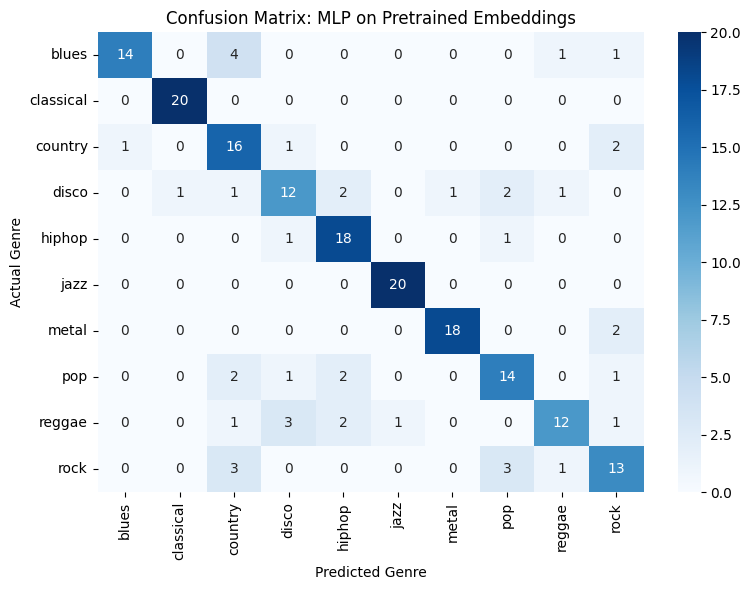

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("--- TASK 4: Downstream MLP Classifier on Pre-Extracted Embeddings ---")

# ==========================================
# 1. Load Pre-Extracted Data
# ==========================================
embeddings_file = "mert_embeddings_95M.npy"
labels_file = "mert_labels_95M.npy"
song_ids_file = "mert_song_ids_95M.npy"

print("Loading pre-extracted MERT embeddings directly into memory...")
X = np.load(embeddings_file)
y_text = np.load(labels_file)
song_ids = np.load(song_ids_file)

# ==========================================
# 2. Strict & Stratified Song-Level Split 
# ==========================================
unique_songs = np.unique(song_ids)

# Map each unique song to its actual genre label for stratification
unique_song_labels = [y_text[np.where(song_ids == song)[0][0]] for song in unique_songs]

train_songs, test_songs = train_test_split(
    unique_songs, 
    test_size=0.2, 
    random_state=42,
    stratify=unique_song_labels
)

# Create masks to reliably filter the data arrays
train_mask = np.isin(song_ids, train_songs)
test_mask = np.isin(song_ids, test_songs)

X_train, X_test = X[train_mask], X[test_mask]
y_train_text, y_test_text = y_text[train_mask], y_text[test_mask]

# Encode text labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_text)
y_test = le.transform(y_test_text)

# ==========================================
# 3. Feature Scaling & MLP Training
# ==========================================
print(f"Dataset shape: Train {X_train.shape}, Test {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training small MLP Classifier (2 fully connected layers)...")
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(256, 128), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    early_stopping=True,     
    n_iter_no_change=10,     
    random_state=42
)

mlp_classifier.fit(X_train_scaled, y_train)
y_pred = mlp_classifier.predict(X_test_scaled)

# ==========================================
# 4. Data Visualization & Metrics Logging
# ==========================================
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*40)
print("TASK 4 CLASSIFICATION METRICS")
print("="*40)
print(f"Classification Accuracy : {acc:.4f}")
print(f"Macro F1-score          : {macro_f1:.4f}")
print("-" * 40)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: MLP on Pretrained Embeddings')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.show()